In [1]:
# Autoreload
%load_ext autoreload
%autoreload 2

from optimizer import Optimizer
from chromosome import Chromosome
from character import Character
from utils import get_item_set, elements
import os
from data import items, item_sets
import json

In [2]:
config = {
            "optimizer" : {
                "path" : "any-sue-pp",
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 30%
                "num_generations": 400,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [
                        6894, # GM pet
                        6895, # GM pet
                        3080, # GM pet
                        9031, # GM pet
                        6980, # Vulbis
                        31886, # Venerable petmount
                              ]  # Excluded items
                },
                "inclusions": {
                    "items": [
                        # 22206, # Alianza de corrupcion
                        # 22205, # Anillo de corrupcion
                        # 7754, # Dofus ocre
                              ]
                },
                "preferences": {
                    "lower": {},
                    "upper": {} 
                },
                "level_offset": 100,  # Level offset for items
                "objective": 25,  # Prospecting
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    # 12:1, # Exo AP
                    # 28:1, # Exo Summons
                    # 8:1
                    },  # Exo MP
                "distributed_points": {
                    # 45: 995,  # Strength
                },
                "elements" : [
                    # 36, # Agility,
                    22, # Chance
                    # 13, # Intelligence
                    # 45  # Strength
                ],
                "melee" : True,
                "ranged" : True
            },
        }

if not os.path.exists(config["optimizer"]["path"]):
    os.makedirs(config["optimizer"]["path"], exist_ok=True)

with open(config["optimizer"]["path"] + '/config.json', 'w') as file:
    json.dump(config, file, indent=4)

In [3]:
import pandas as pd

dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["optimizer"]["language"]],
        "set" : item_set["name"][config["optimizer"]["language"]] if item_set else None,
        "level" : v["level"]
    }
Items = pd.DataFrame.from_dict(dct, orient='index')
# Exclude items from the Gargandias set
config["optimizer"]["exclusions"]["items"] += Items[Items["set"].str.contains("Set de Gargandias",na=False,case=False)].index.tolist()

In [4]:
char = Character(**config["character"])
opt = Optimizer(char,
                 items,
                   item_sets,
                     **config["optimizer"])

Total items: 5565
Total item sets: 285
Total pools:
   16 with sizes [126, 352, 155, 155, 158, 165, 67, 202, 140, 410, 326, 326, 326, 326, 326, 326]
Total combinations: 10^37.41


In [5]:
solutions = opt.optimize(islands = 10, max_workers = 4)

/Users/jdtibochab/miniforge3/envs/other/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/miniforge3/envs/other/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.
  warnings.warn("Use the 'save_best_solutions' parameter with caution as it may cause memory overflow when either the number of generations or number of genes is large.")
/Users/jdtibochab/miniforge3/envs/other/lib/python3.10/site-packages/pygad/pygad.py:1149: UserWarning: Use the 'save_best_solutions' parameter with 

## Analysis

In [6]:
from analysis import Analyzer
analyzer = Analyzer(opt, solutions)
analyzer.run_analysis()

Number of candidate solutions: 277


In [7]:
analyzer.report_extended_results()

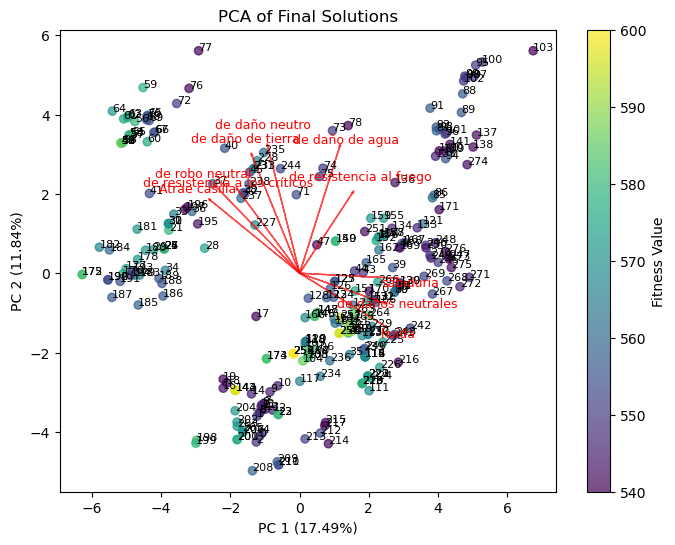

In [8]:
analyzer.plot_pca()

In [9]:
solutions[0].totals

{22: 1246.0,
 9: 2760.0,
 12: 9.0,
 8: 4.0,
 252: 1.0,
 36: 170.0,
 13: 400.0,
 45: 200.0,
 10: 380.0,
 31: 4.0,
 30: 56.0,
 29: 16.0,
 25: 550.0,
 32: 40.0,
 214: 23.0,
 195: 23.0,
 15: 17.0,
 17: 16.0,
 16: 10.0,
 26: 11.0,
 70: 30.0,
 46: -5.0,
 47: 6.0,
 61: 20.0,
 27: 21.0,
 121: 26.0,
 14: 7.0,
 24: 200.0,
 28: 1.0,
 63: 14.0,
 48: 5.0,
 49: 5.0,
 64: 3.0,
 38: 12.0,
 34: 10.0,
 37: 10.0,
 0: 0.0,
 72: 3.0}

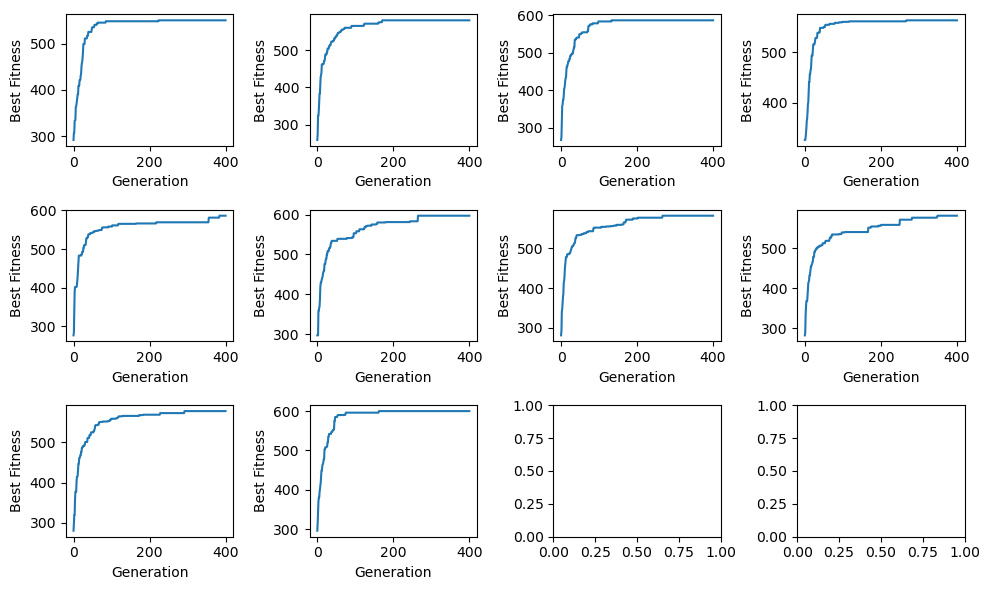

In [10]:
analyzer.report_generations()

In [11]:
assert False

AssertionError: 

In [ ]:
Items[Items["name"].str.contains("anillo de corrupc",case=False)]

In [ ]:
# Test
chr = Chromosome(
                  [
                      19984, 
                      # 11744,
                      14055,
                      22205, 22206, 19983, 15748, 30858, 30860, 15747, 8693, 7043, 7754,
                      13344, 13828, 13759, 694
                  ],
                 opt)
chr.fitness

In [ ]:
Items[Items["name"].str.contains("ling",case=False)]

In [12]:
# Project
chr = Chromosome(
                 [
                    8993, # Espada
                    13641, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    14092, 14093, 18718, # Kuko
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 opt)
chr.fitness

134.0

In [ ]:
chr.set_summary()

In [ ]:
chr.set_summary()["set"].value_counts()

In [ ]:
chr.totals_summary(effect_descriptions)

In [ ]:
Items[Items["name"].str.contains("Chani")]

In [ ]:
item = items[21392]
# item = items[6981]

In [ ]:
chr.are_item_conditions_met(item)

In [ ]:
item

In [ ]:
Items

In [ ]:
lst

In [ ]:
lst[0][2]

In [ ]:
chr.are_item_conditions_met(items[11738])

In [ ]:
items[11738]["conditions"]

In [ ]:
chr.totals[8]

In [ ]:
lst = []
for i in items.values():
    if i["type"]["superTypeId"] not in [i[0] for i in opt.pool_types]:
        continue
    if i["conditions"]:
        print(opt.solution.are_item_conditions_met(i))
        lst.append((i,opt.solution.are_item_conditions_met(i)))

In [ ]:
lst[1]

In [ ]:
lst.count(True), lst.count(False)